### Investigate effect of the loss function

##### 1. Reproduce example presented during the lecture (trade signal)

data shape: (100, 3) 
    Unnamed: 0         X         Y
0           0 -0.015981  0.001984


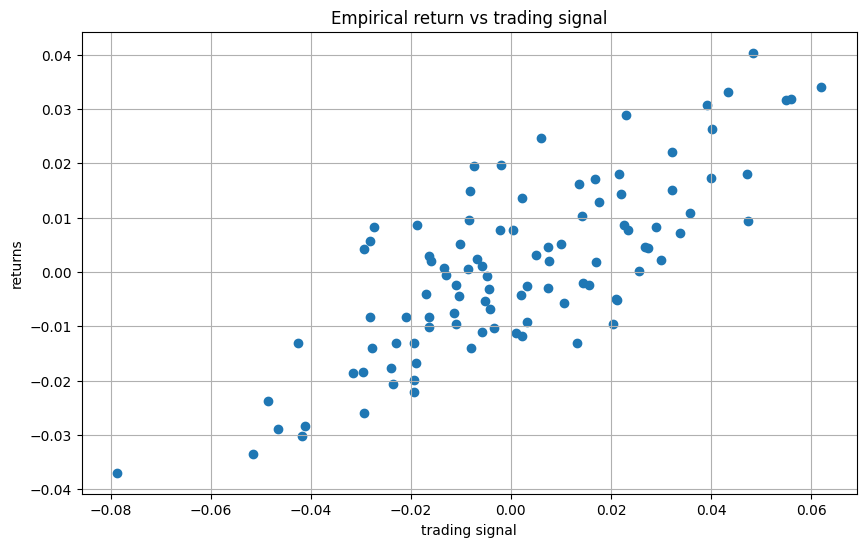

Linear regression result: Y = 0.4688 * X + 0.0002


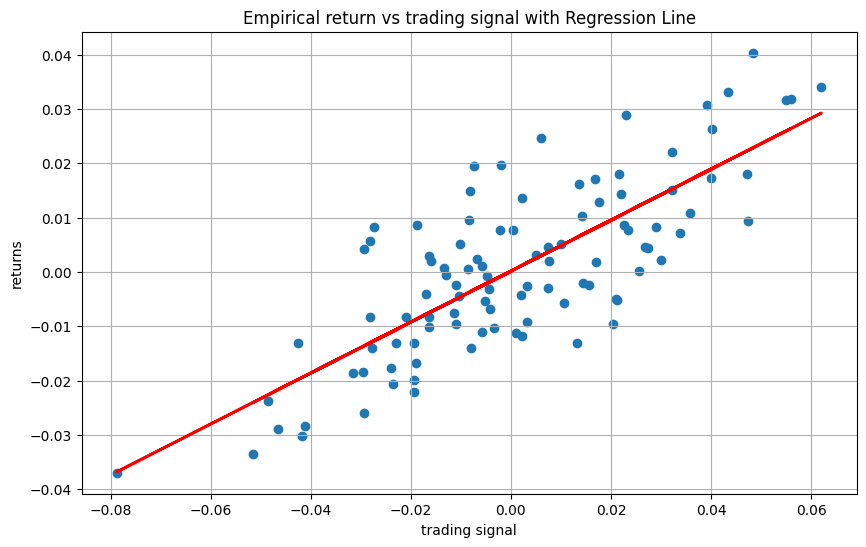

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

data = pd.read_excel('data_9.xlsx')

print("data shape:", data.shape, '\n', data.head(1))

data = data.iloc[:, -2:]

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.title('Empirical return vs trading signal')
plt.xlabel('trading signal')    
plt.ylabel('returns')
plt.grid(True)
plt.show()

reg = LinearRegression().fit(data[['X']], data['Y'])
a = reg.coef_[0]
b = reg.intercept_

print(f"Linear regression result: Y = {a:.4f} * X + {b:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], reg.predict(data[['X']]), color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()



##### 2. Check what happens when:


In [11]:
import pymc as pm  
from scipy.optimize import fmin

X = data['X']
Y = data['Y']
np.random.seed(42)

class tradePredictions:
    def __init__(self, X, Y):
        self._X = X
        self._Y = Y
        with pm.Model() as model:
            std = pm.Uniform("std", 0, 100)
            beta = pm.Normal("beta", mu=0, sigma=100)
            alpha = pm.Normal("alpha", mu=0, sigma=100)
            mean = pm.Deterministic("mean", alpha + beta * X.ravel())
            obs = pm.Normal("obs", mu=mean, sigma=std, observed=Y)
    
            self._idata = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

    def stock_loss(factual, predicted, coef = 100.):
        if factual * predicted < 0:
            return coef * predicted**2 + abs(factual - predicted)
        else:
            return abs(factual - predicted)

    def stock_loss_vect(self, factual_vect, predicted, coef=100):
        loss_vect = np.zeros_like(factual_vect)
        ix_vect = factual_vect * predicted < 0
        loss_vect[ix_vect] = coef * predicted ** 2 + abs(factual_vect[ix_vect] - predicted)
        loss_vect[~ix_vect] = abs(factual_vect[~ix_vect] - predicted)
        return loss_vect.mean()

    def calculate_line(self, coef=100):
        std_samples = self._idata.posterior["std"].values.flatten()
        alpha_samples = self._idata.posterior["alpha"].values.flatten()
        beta_samples = self._idata.posterior["beta"].values.flatten()
        N = std_samples.shape[0]
        
        opt_predictions = np.zeros(50)
        trade_signals = np.linspace(self._X.min(), self._X.max(), 50)
        for i, signal in enumerate(trade_signals):
            noise = std_samples * np.random.randn(N)

            possible_outcomes = alpha_samples + beta_samples * signal + noise
            def tomin(pred):
                return self.stock_loss_vect(possible_outcomes, pred, coef)
            opt_predictions[i] = fmin(tomin, 0, disp=False)

        return trade_signals, opt_predictions

model = tradePredictions(X, Y)

C:\Users\Filip\AppData\Local\Temp\ipykernel_10904\721992705.py:16: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  mean = pm.Deterministic("mean", alpha + beta * X.ravel())
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [std, beta, alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.


 - The quadratic part of the loss function is disabled

[-0.036875  -0.035375  -0.03425   -0.0328125 -0.03125   -0.0301875
 -0.0288125 -0.027125  -0.025875  -0.0245    -0.0233125 -0.022
 -0.0206875 -0.0191875 -0.0179375 -0.0165625 -0.0153125 -0.014
 -0.0124375 -0.01125   -0.0096875 -0.0083125 -0.007125  -0.0053125
 -0.0045625 -0.0030625 -0.0015625 -0.0004375  0.00125    0.0023125
  0.00375    0.005      0.0063125  0.00775    0.0090625  0.0104375
  0.0114375  0.0133125  0.0145     0.015875   0.0170625  0.0185625
  0.0199375  0.021125   0.0225     0.0241875  0.02525    0.0266875
  0.0278125  0.0290625]


C:\Users\Filip\AppData\Local\Temp\ipykernel_10904\721992705.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


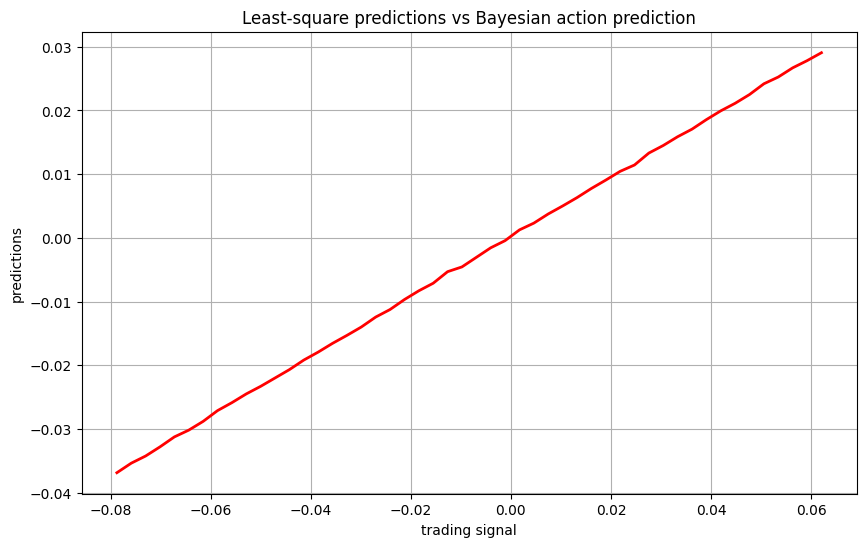

In [20]:
x, res0 = model.calculate_line(0)

print(res0)

plt.figure(figsize=(10, 6))
plt.plot(x, res0, color='red', linewidth=2)
plt.title('Least-square predictions vs Bayesian action prediction')
plt.xlabel('trading signal')
plt.ylabel('predictions')
plt.grid(True)
plt.show()

- The coefficient by which the quadratic part is multiplied is changed to:
    - 500

[-3.67500e-02 -3.51875e-02 -3.36250e-02 -3.23125e-02 -3.05000e-02
 -2.90000e-02 -2.71875e-02 -2.56250e-02 -2.35000e-02 -2.25000e-02
 -1.99375e-02 -1.79375e-02 -1.57500e-02 -1.30625e-02 -1.16875e-02
 -9.56250e-03 -7.93750e-03 -6.31250e-03 -4.81250e-03 -4.12500e-03
 -3.00000e-03 -2.18750e-03 -1.62500e-03 -1.12500e-03 -8.75000e-04
 -5.62500e-04 -2.50000e-04 -6.25000e-05  1.25000e-04  3.75000e-04
  6.87500e-04  9.37500e-04  1.50000e-03  1.93750e-03  2.62500e-03
  3.18750e-03  4.50000e-03  5.43750e-03  6.87500e-03  8.43750e-03
  1.05000e-02  1.23750e-02  1.47500e-02  1.69375e-02  1.88750e-02
  2.09375e-02  2.24375e-02  2.46250e-02  2.62500e-02  2.78750e-02]


C:\Users\Filip\AppData\Local\Temp\ipykernel_10904\721992705.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


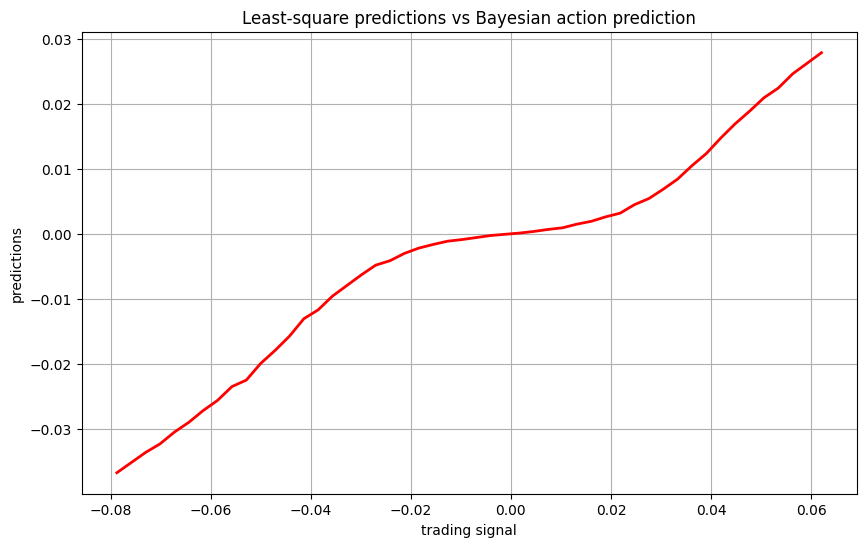

In [19]:
x, res500 = model.calculate_line(500)

print(res500)

plt.figure(figsize=(10, 6))
plt.plot(x, res500, color='red', linewidth=2)
plt.title('Least-square predictions vs Bayesian action prediction')
plt.xlabel('trading signal')
plt.ylabel('predictions')
plt.grid(True)
plt.show()

- 
    - 1000

[-3.65625e-02 -3.46250e-02 -3.30000e-02 -3.20000e-02 -3.05625e-02
 -2.90000e-02 -2.59375e-02 -2.41250e-02 -2.23750e-02 -1.99375e-02
 -1.71250e-02 -1.48750e-02 -1.22500e-02 -1.02500e-02 -8.31250e-03
 -6.50000e-03 -4.56250e-03 -4.06250e-03 -2.93750e-03 -2.31250e-03
 -1.75000e-03 -1.31250e-03 -8.75000e-04 -6.87500e-04 -4.37500e-04
 -3.12500e-04 -1.25000e-04  0.00000e+00  6.25000e-05  1.87500e-04
  3.12500e-04  5.00000e-04  7.50000e-04  1.06250e-03  1.56250e-03
  1.75000e-03  2.50000e-03  3.37500e-03  4.37500e-03  5.43750e-03
  7.25000e-03  9.12500e-03  1.13125e-02  1.37500e-02  1.54375e-02
  1.83125e-02  2.09375e-02  2.27500e-02  2.50625e-02  2.66250e-02]


C:\Users\Filip\AppData\Local\Temp\ipykernel_10904\721992705.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


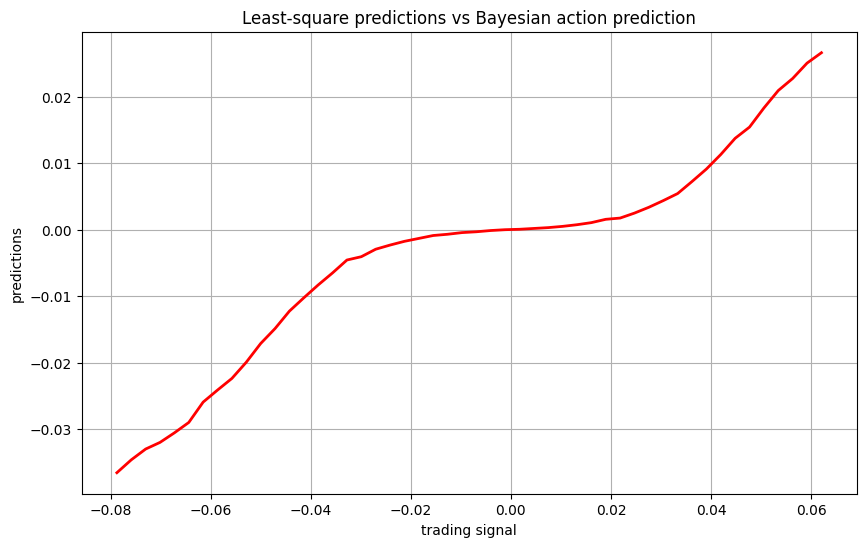

In [18]:
x, res1000 = model.calculate_line(1000)

print(res1000)

plt.figure(figsize=(10, 6))
plt.plot(x, res1000, color='red', linewidth=2)
plt.title('Least-square predictions vs Bayesian action prediction')
plt.xlabel('trading signal')
plt.ylabel('predictions')
plt.grid(True)
plt.show()

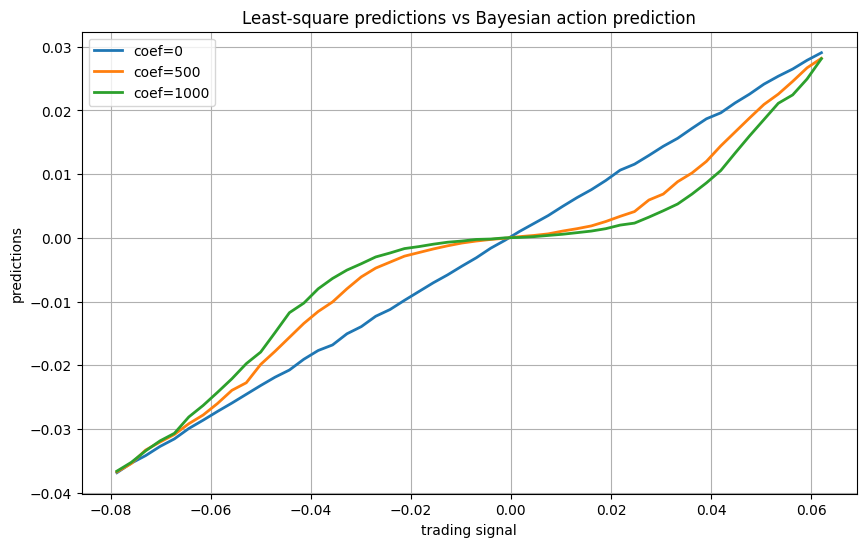

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(x, res0, label='coef=0', linewidth=2)
plt.plot(x, res500, label='coef=500', linewidth=2)
plt.plot(x, res1000, label='coef=1000', linewidth=2)
# plt.scatter(X.ravel(), Y, edgecolors='black', color='red', linewidth=0.5, zorder=1, label='Data Points')
plt.title('Least-square predictions vs Bayesian action prediction')
plt.xlabel('trading signal')
plt.ylabel('predictions')
plt.legend()
plt.grid(True) 
plt.show()

**Wnioski**
- gdy współczynnik coef jest równy 0, nasz wykres zachowuje się praktycznie tak samo jak zwykła regresja liniowa — model traktuje wszystkie błędy jednakowo, bez dodatkowej „kary” za pomyłki w przeciwnym kierunku.
- wraz ze wzrostem wartości coef (np. do 500 czy 1000) linia regresji zaczyna się spłaszczać w okolicach zera. Oznacza to, że model staje się bardziej „ostrożny” — nie chce przewidywać dużych wartości, jeśli nie ma co do tego wyraźnych dowodów w danych.
- im wyższy współczynnik coef, tym model bardziej boi się popełnić kosztowny błąd (np. przewidzieć wzrost, gdy w rzeczywistości spadek). Dlatego woli nic nie robić (czyli prognozować blisko zera), dopóki nie ma bardzo silnego sygnału.
- przy małym coef model jest impulsywny – reaguje na każdy drobny sygnał, nawet jeśli może się mylić.
- przy dużym coef model jest ostrożny – wchodzi na rynek tylko wtedy, gdy sygnał jest naprawdę wyraźny i pewny.